# EDA / DV  

Durley Galvan Jimenez
AndrewID: dgalvanj

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
import geoplot as gplt
import geopandas as gpd
import folium
import plotly.io as pio

# Set default renderer for Plotly
pio.renderers.default = 'notebook'

# Executive Summary

This project analyzes the longitudinal trends in English Competency Scores in Colombian high schools over the five-year period from 2020 to 2024, utilizing comprehensive dataset from the Colombian Institute for the Evaluation of Education (ICFES - Examen Saber 11). The primary objective was to determine the overall trajectory of English proficiency—specifically whether average scores have increased, decreased, or remained linear—and to critically evaluate the performance gap between Public (Calendar A) and Private (Calendar B) educational institutions.

# Data Source

The data originates from the Colombian Institute for the Evaluation of Education (ICFES), an autonomous, government-affiliated body responsible for evaluating the quality of education across Colombia. The data is derived from the Saber 11 Examination, which is the mandatory national high school exit exam taken by all students completing secondary education (11th grade).

Standardization: The Saber 11 is a standardized, high-stakes test used as the primary metric for assessing academic skills and is a major requirement for university admission across the country. This standardization ensures that the scores are directly comparable across different schools, regions, and years.

# Understanding The Data

We started with ten big files of test scores from the Colombian government (ICFES), covering five years of exams (2020–2024).
1.  Finding the Right Information:
We had to read the website's instruction manual (the "data dictionary") very carefully. This manual told us exactly what all the columns and codes meant, so we could be sure we were using the correct English score column and correctly identifying the school types.
2.  Managing the Big Files (LFS) 
Since the data files were too large to store directly in our project's version control system (GitHub), we used a special tool called Git LFS (Large File Storage). Think of it like a locker service for files: we kept small placeholder notes in our project, and the huge files were safely stored away. This made our project manageable and easy for others to download.
3.   Cleaning and Combining Everything
We used Python to take all ten files and piled them on top of each other into one single, giant table called a DataFrame. As we combined them, we only kept the columns that we need for our project.
4.  Finally, we took out any rows that had missing or blank scores in the English competency column. This critical step made sure our final charts would only use perfect, reliable data.

This entire process resulted in one clean, solid table, perfectly ready for charting the English score trends and comparing school types.

In [2]:
# Step 1 — define columns to keep  
columns_to_keep = [
    'periodo',
    'cole_naturaleza',
    'cole_bilingue',
    'cole_depto_ubicacion',
    'punt_ingles',
    'desemp_ingles',
    'cole_calendario',
    'estu_genero'
]

# Step 2 — get the data files  

file_paths = [
    'Examen_Saber_11_20201.txt',
    'Examen_Saber_11_20202.txt',
    'Examen_Saber_11_20211.txt',
    'Examen_Saber_11_20212.txt',
    'Examen_Saber_11_20221.txt',
    'Examen_Saber_11_20222.txt',
    'Examen_Saber_11_20231.txt',
    'Examen_Saber_11_20232.txt',
    'Examen_Saber_11_20241.txt',
    'Examen_Saber_11_20242.txt',
]

df_list = []
for fpath in file_paths:
    # Step 3 — read each file
    # If txt is tab-separated or other delim, adjust sep argument accordingly
    df = pd.read_csv(fpath, sep=None, engine='python')
    # Step 4 — keep only needed columns (ignore others)
    df = df.loc[:, columns_to_keep]
    # Step 5 — derive a 'year' column from filename or periodo
    m = re.search(r'(\d{4})\d$', fpath)
    if m:
        df['year'] = int(m.group(1))
    else:
        # fallback: derive year from 'periodo' column (first 4 digits)
        df['year'] = df['periodo'].astype(str).str[:4].astype(int)
    df_list.append(df)

# Step 6 — combine all exam-files into a single “master” DataFrame  
df_all = pd.concat(df_list, ignore_index=True)

# Step 7 — drop rows without English score or performance  
df_all = df_all.dropna(subset=['punt_ingles', 'desemp_ingles'])

# Now df_all is ready for analysis

#print(df_all.head())

# Visualizations  

In [3]:
# Step 8 — compute per-year aggregated metrics: average score, and category distribution  
# 8a: average English score per year  
avg_df = df_all.groupby('year')['punt_ingles'].mean().reset_index()

# ------------------    visualize the trend over years -----------------------
# 9a — line chart: average English score per year  
fig1 = px.line(
    avg_df,
    x='year',
    y='punt_ingles',
    title='Avg English Score per Year (all exams combined)',
    labels={'year':'Year', 'punt_ingles':'Average English Score'},
    markers=True,           # <— show markers on each data point
    text='punt_ingles'      # <— add the y‑value as text label at each point
)

fig1.update_traces(
    texttemplate='%{y:.1f}',        # format the label (one decimal, e.g. 76.5)
    textposition='top center',      # position labels above the markers
    marker=dict(size=8, color='blue')  
)

fig1.update_yaxes(range=[0, 100])   
fig1.show()




# Line Chart

It calculates the average English score (punt_ingles) for all students across all exams combined for each year (avg_df).
We can conclude that it has been only a slight, marginal improvement since 2020. This indicates a near-stagnant overall national performance over the five-year period.

In [4]:

desired_order = ["A-", "A1", "A2", "B1", "B+"]  
cat_df = df_all.groupby(['year', 'desemp_ingles']).size().reset_index(name='count')
cat_df['pct'] = cat_df.groupby('year')['count'].transform(lambda x: x / x.sum())
cat_df['pct_str'] = (cat_df['pct'] * 100).round(1).astype(str) + '%'

fig2 = px.bar(
    cat_df,
    x='year',
    y='pct',
    color='desemp_ingles',
    category_orders={'desemp_ingles': desired_order},
    title='Distribution of English Performance Categories per Year (in %)',
    labels={'pct':'Proportion', 'year':'Year', 'desemp_ingles':'Category'},
    text='pct_str',
     height=800,
        width=900
)
fig2.update_traces(
    textposition='inside',insidetextfont=dict(size=15, color='white'), )
fig2.update_layout(yaxis=dict(tickformat=".0%"))  # optional: show axis in percent
fig2.show()

# Stacked Bar Chart

This stacked bar chart, showing the distribution of English performance categories from 2020 to 2024, reveals a critical challenge in national English education: low proficiency is overwhelmingly prevalent among graduating students.

## Key Findings:

1. Concentration at the Base: The analysis confirms that the vast majority of students are concentrated in the two lowest performance bands: A- and A1. The A- category (the lowest measured level) is consistently the largest single group across all five years.

2. Stagnant Distribution: Crucially, the distribution of these categories remains highly stable throughout the 2020-2024 period. This indicates that while there may be marginal score improvements, the system is not successfully shifting large groups of students out of the lowest proficiency bands from year to year.

3. Minimal High Proficiency: Conversely, the percentage of students achieving truly functional or independent proficiency (categories B+ and B1) remains critically low, accounting for a minimal fraction of the total student body in every single year observed.

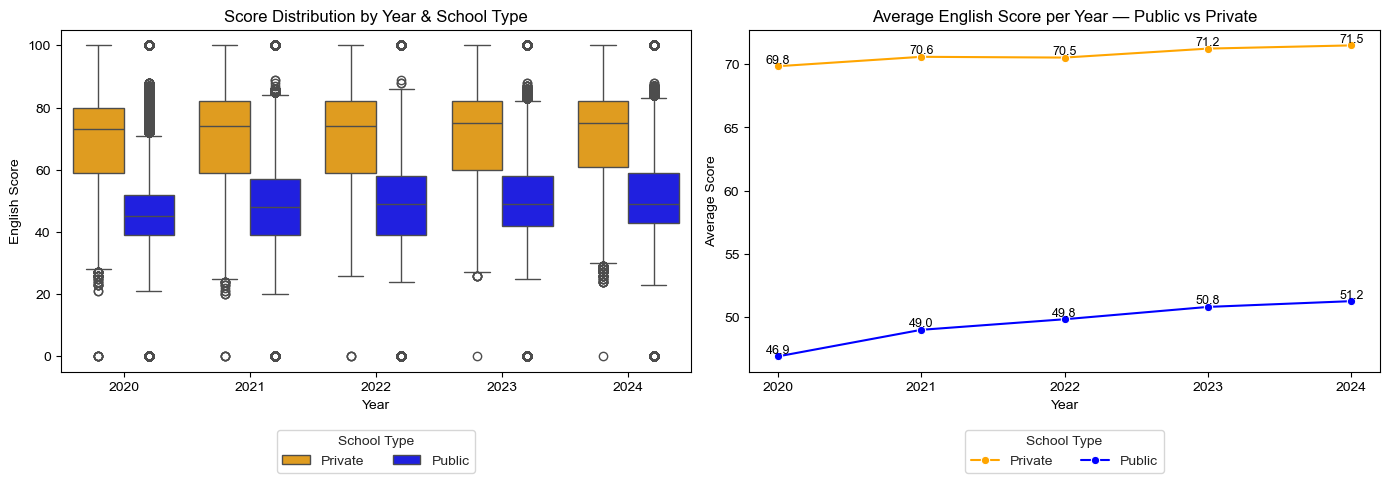

In [5]:
df = df_all.copy()
df = df[df['cole_calendario'].isin(['A','B'])]  
df['year'] = df['periodo'].astype(str).str[:4].astype(int)
df['school_type'] = df['cole_calendario'].map({'A':'Public','B':'Private'})

# Prepare aggregated data for line chart
avg_df = df.groupby(['year','school_type'])['punt_ingles'].mean().reset_index(name='avg_score')

# Create a figure with 1 row and 2 columns (1×2)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharey=False)
ax1, ax2 = axes.flatten()

sns.set_style("whitegrid")

# ---------------------------- BOXPLOT on ax1 -----------------------------------------
sns.boxplot(
    data=df,
    x='year', y='punt_ingles',
    hue='school_type',
    palette={'Public':'blue', 'Private':'orange'},
    ax=ax1
)

ax1.set_title('Score Distribution by Year & School Type')
ax1.set_xlabel('Year')
ax1.set_ylabel('English Score')


# Move legend of this subplot downward / outside the plot

ax1.legend(
    title='School Type',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),  
    ncol=2
)

# Ensure the boxplot y‑axis ticks/labels are visible
ax1.yaxis.set_visible(True)   # should be by default

ax1.tick_params(axis='y', which='both', labelsize=10)

# -------------------------- LINE CHART on ax2 -----------------------------------
sns.lineplot(
    data=avg_df,
    x='year', y='avg_score',
    hue='school_type',
    marker='o',
    palette={'Public':'blue', 'Private':'orange'},
    ax=ax2
)
for school in avg_df['school_type'].unique():
    sub = avg_df[avg_df['school_type'] == school]
    for _, row in sub.iterrows():
        ax2.text(
            row['year'], row['avg_score'],
            f"{row['avg_score']:.1f}",
            ha='center', va='bottom', fontsize=9, color='black'
        )

ax2.set_title('Average English Score per Year — Public vs Private')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Score')
ax2.set_xticks(sorted(df['year'].unique()))

# Optionally reposition/adjust legend for ax2 too
ax2.legend(
    title='School Type',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
plt.show()

# Comparative Performance of Public (calendar A) vs. Private Schools(calendar B) 

The side-by-side visualization, combining the score distribution (Boxplot) and the average score trend (Line Chart), conclusively demonstrates a persistent and significant performance gap in English competency between private (Calendar B) and public (Calendar A) schools over the five-year period (2020–2024).

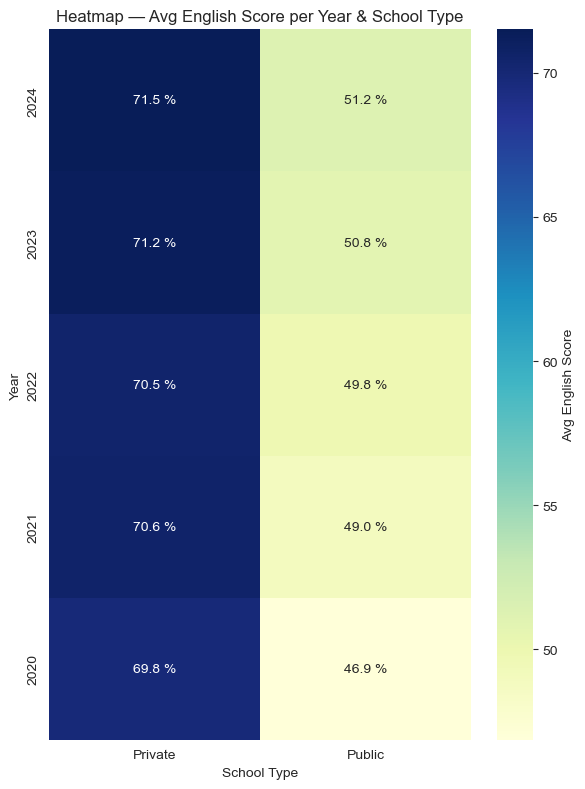

In [6]:
df = df_all.copy()
df = df[df['cole_calendario'].isin(['A', 'B'])]  # keep only valid calendar
df['year'] = df['periodo'].astype(str).str[:4].astype(int)
df['school_type'] = df['cole_calendario'].map({'A':'Public','B':'Private'})

# Aggregate: average score per year × school type
agg = (df
       .groupby(['year', 'school_type'])['punt_ingles']
       .mean()
       .reset_index())

# Pivot for heatmap: rows = year; columns = school_type
pivot = agg.pivot(index='year', columns='school_type', values='punt_ingles')

plt.figure(figsize=(6, 8))
ax = sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu",
                 cbar_kws={'label': 'Avg English Score'})
for t in ax.texts:
    # t.get_text() returns the current text (e.g. "78.4")
    t.set_text(t.get_text() + " %")

ax.set_xlabel("School Type")
ax.set_ylabel("Year")

# Invert y‑axis so earliest year at bottom
ax.invert_yaxis()

plt.title("Heatmap — Avg English Score per Year & School Type")
plt.tight_layout()
plt.show()


# Heatmap of Public (calendar A) vs. Private Schools(calendar B) 

This visualization provides another comparison between public and private schools, which again confirms the predominance of private schools in achieving the highest scores, overshadowing any year-to-year national fluctuations.

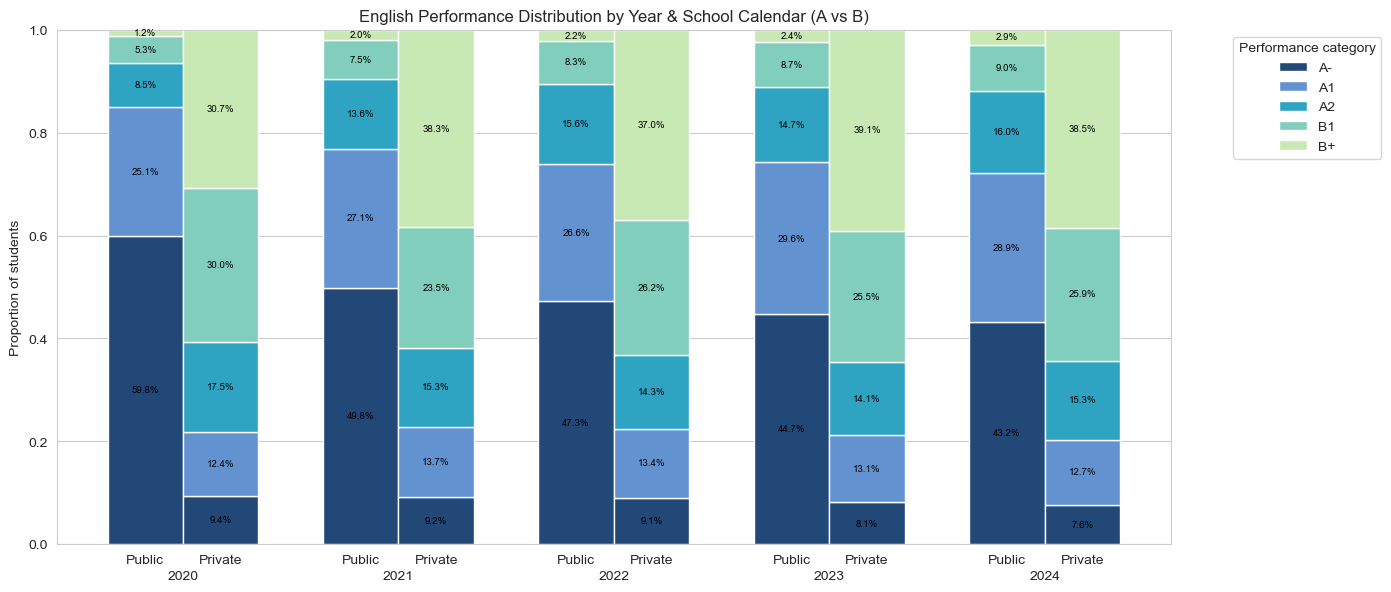

In [7]:

df = df_all.copy()
df = df[df['cole_calendario'].isin(['A', 'B'])]
df['year'] = df['periodo'].astype(str).str[:4].astype(int)

cat_df = (
    df
    .groupby(['year', 'cole_calendario', 'desemp_ingles'])
    .size()
    .reset_index(name='count')
)
cat_df['pct'] = cat_df.groupby(['year', 'cole_calendario'])['count'].transform(lambda x: x / x.sum())

pivot = cat_df.pivot_table(
    index=['year','cole_calendario'],
    columns='desemp_ingles',
    values='pct',
    fill_value=0
)

color_for_category = {
    'A-': '#214877',   
    'A1': "#6293D0",  
    'A2':  '#2fa3c2',  
    'B1': '#80cebb',  
    'B+': '#c8e9b4',
}
category_order = [cat for cat in color_for_category.keys() if cat in pivot.columns]

years = sorted(df['year'].unique())
calendars = ['A', 'B']
bar_width = 0.35
x = np.arange(len(years))  # one position per year‑group center

fig, ax = plt.subplots(figsize=(14, 6))

# Plot bars (public vs private per year, stacked by categories)
for j, cal in enumerate(calendars):
    bottoms = np.zeros(len(years))
    for cat in category_order:
        vals = [
            pivot.loc[(yr, cal), cat] if (yr, cal) in pivot.index else 0
            for yr in years
        ]
        ax.bar(
            x + (j - 0.5)*bar_width,
            vals,
            bar_width,
            bottom=bottoms,
            color=color_for_category.get(cat, None),
            label=(cat if j == 0 else None)
        )
        bottoms += vals

# annotate inside bars — modified
for j, cal in enumerate(calendars):
    for i, yr in enumerate(years):
        bottom = 0.0
        for cat in category_order:
            val = pivot.loc[(yr, cal), cat] if (yr, cal) in pivot.index else 0
            # Remove or lower threshold
            if val > 0:  
                ax.text(
                    x[i] + (j - 0.5)*bar_width,
                    bottom + val/2,
                    f"{val*100:.1f}%",  # or maybe fewer decimals
                    ha='center', va='center',
                    fontsize=7,   # smaller font may help
                    color='black' if val > 0.05 else 'black'  # maybe switch text color
                )
            bottom += val

# Set axis labels / title
ax.set_ylabel('Proportion of students')
ax.set_title('English Performance Distribution by Year & School Calendar (A vs B)')
plt.ylim(0, 1)

# Set Public/Private labels under each bar
tick_positions = []
tick_labels = []
for i, yr in enumerate(years):
    for j, cal in enumerate(calendars):
        xpos = x[i] + (j - 0.5)*bar_width
        tick_positions.append(xpos)
        tick_labels.append('Public' if cal == 'A' else 'Private')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

# — Add the year label under each group (centered between the two bars)
for i, yr in enumerate(years):
    ax.text(
        x[i],                # group center
        -0.05,               # slightly below x‑axis
        str(yr),
        ha='center',
        va='top',
        transform=ax.get_xaxis_transform()
    )

# Legend for performance categories (colors)
ax.legend(title='Performance category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# Side-by-Side Stacked Bar of Public (calendar A) vs. Private Schools(calendar B) 

This side-by-side stacked bar chart provides the ultimate visual proof of the structural disparity in English competency by simultaneously comparing the detailed performance breakdown of public and private schools across five years.

In [8]:
# 1. Load  geojson
gdf = gpd.read_file("co.json")

# 2. (Your data‑prep + merging) … produce a GeoDataFrame map_df with 'avg_ingles' & department names
# For example:
df = df_all.copy()
df = df.dropna(subset=['punt_ingles', 'cole_depto_ubicacion'])
dept_avg = df.groupby('cole_depto_ubicacion')['punt_ingles'].mean().reset_index(name='avg_ingles')

# Clean / standardize names as you already did (dept_clean), then merge
gdf['dept_clean'] = (gdf['name']
                     .str.strip()
                     .str.upper()
                     .str.normalize('NFKD')
                     .str.encode('ascii', errors='ignore').str.decode('utf-8'))
dept_avg['dept_clean'] = (dept_avg['cole_depto_ubicacion']
                         .str.strip()
                         .str.upper()
                         .str.normalize('NFKD')
                         .str.encode('ascii', errors='ignore').str.decode('utf-8'))
# include manual name mapping if needed
name_map = {
    'VALLE': 'VALLE DEL CAUCA',
    'BOGOTA': 'DISTRITO CAPITAL DE BOGOTA',
    'SAN ANDRES': 'SAN ANDRES Y PROVIDENCIA',
    'NORTE SANTANDER': 'NORTE DE SANTANDER',
    # add more if needed
}
dept_avg['dept_clean'] = dept_avg['dept_clean'].replace(name_map)

map_df = gdf.merge(dept_avg, left_on='dept_clean', right_on='dept_clean', how='left')

# Optionally, convert CRS so it's lat/lon (EPSG:4326) if required for folium
map_df = map_df.to_crs(epsg=4326)

# 3. Create interactive map via geopandas/folium .explore()
m = map_df.explore(
    column='avg_ingles',              # numeric column for coloring
    tooltip=['name', 'avg_ingles'],   # show dept name + average on hover
    cmap='YlGnBu',                     # colormap
    legend=True,
    tiles='CartoDB positron',         # base map style
    edgecolor='black',
    linewidth=0.2
)

# 4. Show or save the map
m.save("colombia_english_scores_map.html")
m  


# Map 

The map generated by this code provides a visualization of English competency scores across Colombia, offering a clear geographical perspective on performance. Where the departments are color-coded based on their average score. The color intensity (darker colors for higher scores) allows for immediate identification of regional disparities.

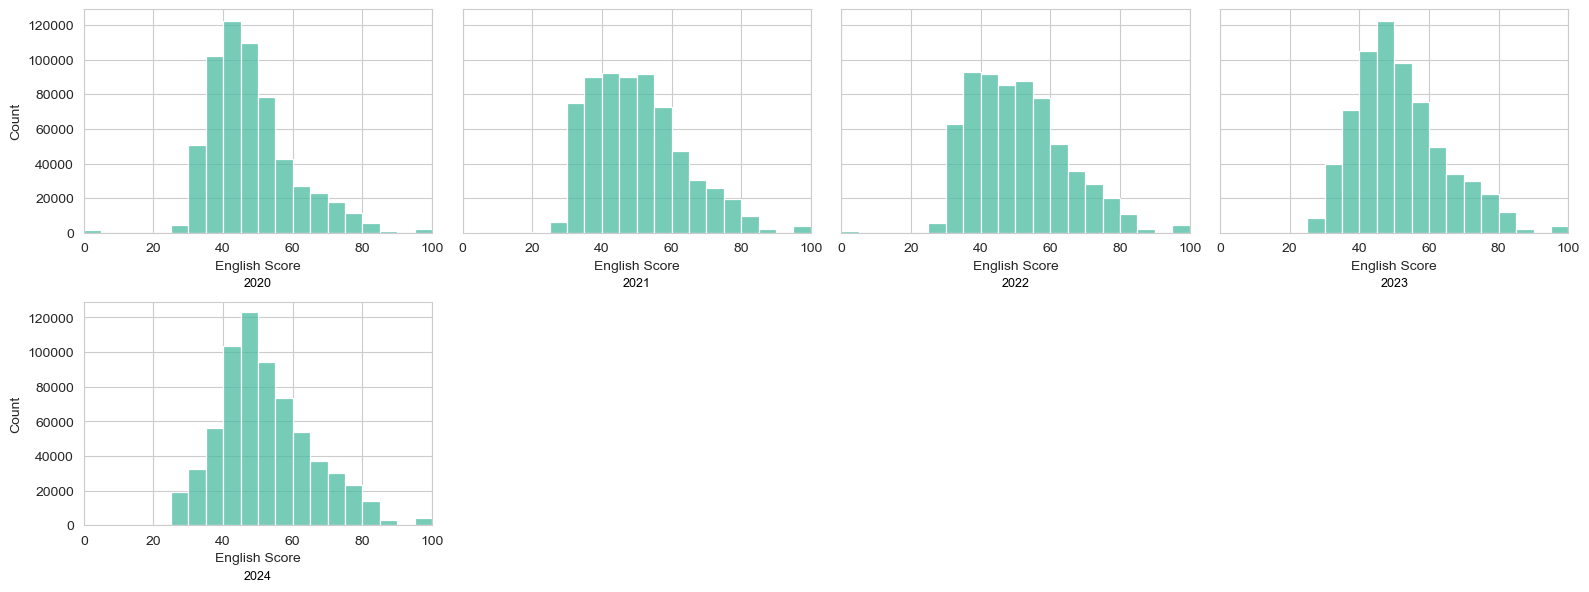

In [9]:

df = df_all.copy()

df = df.dropna(subset=['punt_ingles', 'year'])
df['year'] = df['year'].astype(int)

years = sorted(df['year'].unique())

# Plot parameters
n_cols = 4
n_rows = (len(years) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), sharey=True)

sns.set_style("whitegrid")
hist_color = "#4abba1"  # or any color you choose
n_bins = 20  # or adjust depending on score range

for ax, yr in zip(axes.flatten(), years):
    subset = df[df['year'] == yr]
    sns.histplot(
        data=subset,
        x='punt_ingles',
        bins=n_bins,
        color=hist_color,
        ax=ax
    )
    #ax.set_title(f"Distribution of English Scores by Year")  
    ax.set_xlabel("English Score")
    ax.set_ylabel("Count")
    ax.set_xlim(df['punt_ingles'].min(), df['punt_ingles'].max())
    # put the year label at bottom, or as title:
    ax.text(
        0.5, -0.20, str(yr),
        ha='center', va='top',
        transform=ax.transAxes,
        fontsize=9,
        color='black'
    )

# Hide empty axes (if any)
total_plots = n_rows * n_cols
for idx in range(len(years), total_plots):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()


# Histograms 

A clear conclusion in these visualisation is that there is a stable underlying distributional shape: right skew, meaning for all years many students cluster around lower/middle scores and fewer reach top scores. Reminding us again that studnets remain in low score in English. 

# Conclusion:

Based on the visualization and analysis of the ICFES Saber 11 examination data from 2020 to 2024, this project confirms that achieving high levels of English competency remains one of the most significant challenges in the Colombian education system.
On the other hand, while the data shows a slight national improvement, the primary impediment to raising overall English competency is the pronounced, stable, and geographically concentrated performance gap between public and private education. Future policy interventions must move beyond national averages and focus explicitly on targeted resource allocation and strategic investment in Public School (Calendar A) institutions and geographically disadvantaged regions to address this structural inequity.